# Semana 9 - Ejercicio 3: Evaluación de un Árbol de Clasificación

**Materia:** Minería de Datos  
**Tema:** Evaluación de Modelos de Clasificación  
**Estudiante:** Sara Valenzuela

## Objetivo

Evaluar el desempeño de un árbol de decisión utilizando métricas de clasificación como Accuracy, Matriz de Confusión y Classification Report.

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [19]:
# Cargar dataset
df = sns.load_dataset("penguins")

# Eliminar valores faltantes
df = df.dropna()

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [20]:
# Variables predictoras
X = df[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

# Variable objetivo
y = df["species"]

# División entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (266, 4)
Prueba: (67, 4)


## Preparación de los datos

Se utilizaron características físicas de los pingüinos para predecir su especie.

El conjunto de datos fue dividido en entrenamiento (80%) y prueba (20%) para evaluar el rendimiento del modelo sobre datos no observados durante el entrenamiento.

In [21]:
tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [22]:
y_pred = tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9850746268656716


In [23]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[30  1  0]
 [ 0 13  0]
 [ 0  0 23]]


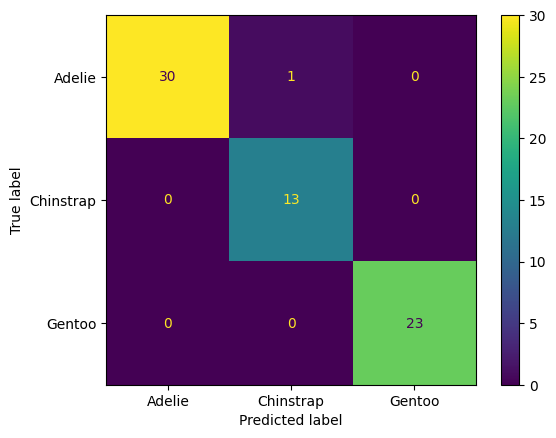

In [24]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=tree.classes_
)

disp.plot()

plt.show()

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        31
   Chinstrap       0.93      1.00      0.96        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



## Conclusión Final

El árbol de decisión obtuvo una precisión global de 98,51%, demostrando una elevada capacidad para clasificar correctamente las especies de pingüinos.

La matriz de confusión mostró únicamente un error de clasificación, mientras que el resto de los ejemplares fueron identificados correctamente. Asimismo, las métricas Precision, Recall y F1-Score alcanzaron valores cercanos a 1 para todas las especies evaluadas.

Estos resultados indican que las variables utilizadas poseen un alto poder discriminatorio y permiten diferenciar eficazmente las especies Adelie, Chinstrap y Gentoo.

En conclusión, el modelo presenta un excelente desempeño y constituye una herramienta efectiva para tareas de clasificación dentro del contexto de minería de datos.